# Steady-State Heat Conduction — 1D

This notebook demonstrates `solve_steady()` for one-dimensional steady-state conduction.

We solve the general equation

$$\frac{d}{dx}\!\left(k(T)\,\frac{dT}{dx}\right) = 0, \quad x \in [0,1]$$

| Case | Conductivity $k$ | Exact solution |
|------|-----------------|----------------|
| **Linear** | $k = 1$ | $T = 1 - x$ |
| **Nonlinear** | $k = 1 + T^2$ | implicit (BVP reference) |

`solve_steady()` delegates to `scipy.optimize.root` (default method `'hybr'`).
For the **linear** case Newton converges in **one iteration** — no penalty versus a direct solve.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import sys; sys.path.insert(0, '..')   # adjust if upde is installed as a package
from upde import PDE
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

x = np.linspace(0, 1, 200)


## Case 1 — Linear ($k = 1$)

$$\frac{d^2 T}{dx^2} = 0, \qquad T(0) = 1,\quad T(1) = 0$$

Exact solution: $T(x) = 1 - x$.


In [7]:
eq = PDE('T', x=x)
eq.add_diffusion(diffusivity=1.0)
eq.set_bc(side='left',  kind='dirichlet', value=1.0)
eq.set_bc(side='right', kind='dirichlet', value=0.0)

sol = eq.solve_steady()
print(sol)
print(f"Max error vs exact: {np.max(np.abs(sol.T - (1 - x))):.2e}")


SteadySolution(fields=['T'], shape=(200,), success=True, residual=4.40e-12, nfev=217)
Max error vs exact: 1.11e-16


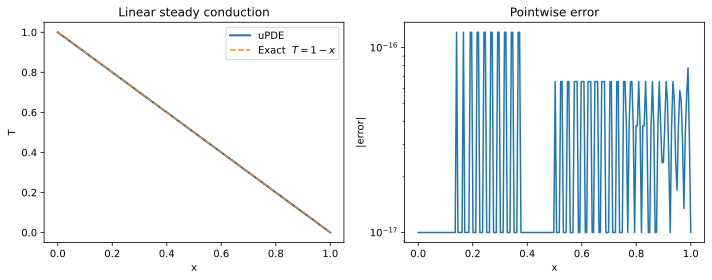

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(x, sol.T, lw=2, label='uPDE')
axes[0].plot(x, 1 - x, '--', lw=1.5, label='Exact  $T = 1-x$')
axes[0].set(xlabel='x', ylabel='T', title='Linear steady conduction')
axes[0].legend()

axes[1].semilogy(x, np.abs(sol.T - (1 - x)) + 1e-17)
axes[1].set(xlabel='x', ylabel='|error|', title='Pointwise error')

plt.tight_layout()
plt.show()


## Case 2 — Nonlinear ($k = 1 + T^2$)

$$\frac{d}{dx}\!\left((1 + T^2)\frac{dT}{dx}\right) = 0,
  \qquad T(0) = 1,\quad T(1) = 0$$

No closed-form $T(x)$, but the first integral $T + T^3/3 = c_1 x + c_2$ can be solved
numerically with `scipy.integrate.solve_bvp` as a high-accuracy reference.

A linear ramp between the BCs is a sufficient starting guess.


In [9]:
from scipy.integrate import solve_bvp

# High-accuracy BVP reference
def bvp_fun(x, y):
    T, dT = y
    return np.vstack([dT, -2*T*dT**2 / (1 + T**2)])

def bvp_bc(ya, yb):
    return np.array([ya[0] - 1.0, yb[0] - 0.0])

x_ref = np.linspace(0, 1, 500)
y0    = np.zeros((2, x_ref.size))
y0[0] = np.linspace(1, 0, x_ref.size)
ref   = solve_bvp(bvp_fun, bvp_bc, x_ref, y0, tol=1e-10)
T_ref = ref.sol(x)[0]

# uPDE steady solve
eq_nl = PDE('T', x=x)
eq_nl.add_diffusion(diffusivity=lambda x, T: 1.0 + T**2)
eq_nl.set_bc(side='left',  kind='dirichlet', value=1.0)
eq_nl.set_bc(side='right', kind='dirichlet', value=0.0)

sol_nl = eq_nl.solve_steady(guess=np.linspace(1.0, 0.0, len(x)))
print(sol_nl)
print(f"Max error vs BVP reference: {np.max(np.abs(sol_nl.T - T_ref)):.2e}")


SteadySolution(fields=['T'], shape=(200,), success=True, residual=1.11e-07, nfev=209)
Max error vs BVP reference: 6.89e-06


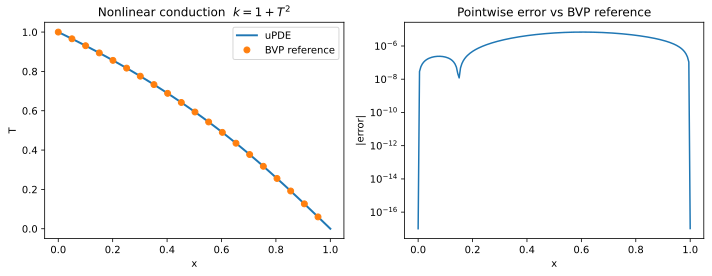

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(x, sol_nl.T, lw=2, label='uPDE')
axes[0].plot(x, T_ref, 'o', markevery=10, lw=1.5, label='BVP reference')
axes[0].set(xlabel='x', ylabel='T', title=r'Nonlinear conduction  $k = 1+T^2$')
axes[0].legend()

axes[1].semilogy(x, np.abs(sol_nl.T - T_ref) + 1e-17)
axes[1].set(xlabel='x', ylabel='|error|', title='Pointwise error vs BVP reference')

plt.tight_layout()
plt.show()


## Summary

| Case | Residual | Error | Notes |
|------|----------|-------|-------|
| Linear ($k=1$) | $O(10^{-12})$ | machine precision | 1 Newton step |
| Nonlinear ($k=1+T^2$) | $O(10^{-7})$ | $O(\Delta x^2)$ | a few Newton steps |

`solve_steady()` handles both cases with the same one-line call — no flag, no branching.
